<a href="https://colab.research.google.com/github/souptikmaiti/building-llm/blob/main/003_Token_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import trained model

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.8 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### Example of a word as a vector

In [ ]:
word_vectors = model # its a dictionary, key is word, value is the 300 dim vector
print(word_vectors['computer'])


[ 1.07421875e-01 -2.01171875e-01  1.23046875e-01  2.11914062e-01
 -9.13085938e-02  2.16796875e-01 -1.31835938e-01  8.30078125e-02
  2.02148438e-01  4.78515625e-02  3.66210938e-02 -2.45361328e-02
  2.39257812e-02 -1.60156250e-01 -2.61230469e-02  9.71679688e-02
 -6.34765625e-02  1.84570312e-01  1.70898438e-01 -1.63085938e-01
 -1.09375000e-01  1.49414062e-01 -4.65393066e-04  9.61914062e-02
  1.68945312e-01  2.60925293e-03  8.93554688e-02  6.49414062e-02
  3.56445312e-02 -6.93359375e-02 -1.46484375e-01 -1.21093750e-01
 -2.27539062e-01  2.45361328e-02 -1.24511719e-01 -3.18359375e-01
 -2.20703125e-01  1.30859375e-01  3.66210938e-02 -3.63769531e-02
 -1.13281250e-01  1.95312500e-01  9.76562500e-02  1.26953125e-01
  6.59179688e-02  6.93359375e-02  1.02539062e-02  1.75781250e-01
 -1.68945312e-01  1.21307373e-03 -2.98828125e-01 -1.15234375e-01
  5.66406250e-02 -1.77734375e-01 -2.08984375e-01  1.76757812e-01
  2.38037109e-02 -2.57812500e-01 -4.46777344e-02  1.88476562e-01
  5.51757812e-02  5.02929

In [ ]:
print(word_vectors['cat'].shape)

(300,)


### king + woman - man =?

In [ ]:
print(word_vectors.most_similar(positive=['king', 'woman'], negative=['man'], topn=10))

[('queen', 0.7118193507194519), ('monarch', 0.6189674139022827), ('princess', 0.5902431011199951), ('crown_prince', 0.5499460697174072), ('prince', 0.5377321839332581), ('kings', 0.5236844420433044), ('Queen_Consort', 0.5235945582389832), ('queens', 0.518113374710083), ('sultan', 0.5098593235015869), ('monarchy', 0.5087411403656006)]


In [ ]:
print(word_vectors.similarity('woman', 'man'))
print(word_vectors.similarity('king', 'queen'))
print(word_vectors.similarity('uncle', 'aunt'))
print(word_vectors.similarity('dog', 'puppy'))
print(word_vectors.similarity('paper', 'water'))
print(word_vectors.similarity('water', 'ice'))

0.76640123
0.6510957
0.7643474
0.81064284
0.11408084
0.3523432


In [ ]:
print(word_vectors.most_similar('tower', topn=5))

[('towers', 0.8531750440597534), ('skyscraper', 0.6417425870895386), ('Tower', 0.639177143573761), ('spire', 0.594687819480896), ('responded_Understood_Atlasjet', 0.5931612253189087)]


In [ ]:
import numpy as np

In [ ]:
print(np.linalg.norm(word_vectors['man']-word_vectors['woman']))
print(np.linalg.norm(word_vectors['semiconductor']-word_vectors['silicon']))
print(np.linalg.norm(word_vectors['semiconductor']-word_vectors['earthworm']))

1.727951
3.1410015
5.6670427


## Creating Token Embeddings

In [ ]:
import torch

In [ ]:
input_ids = torch.tensor([2,3,5,1])

### Assume vocab size = 6 and vector dim = 3

In [ ]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


### Embedding layer is just a look up table, where we can get the embedding just by querying with the token id

In [ ]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [ ]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


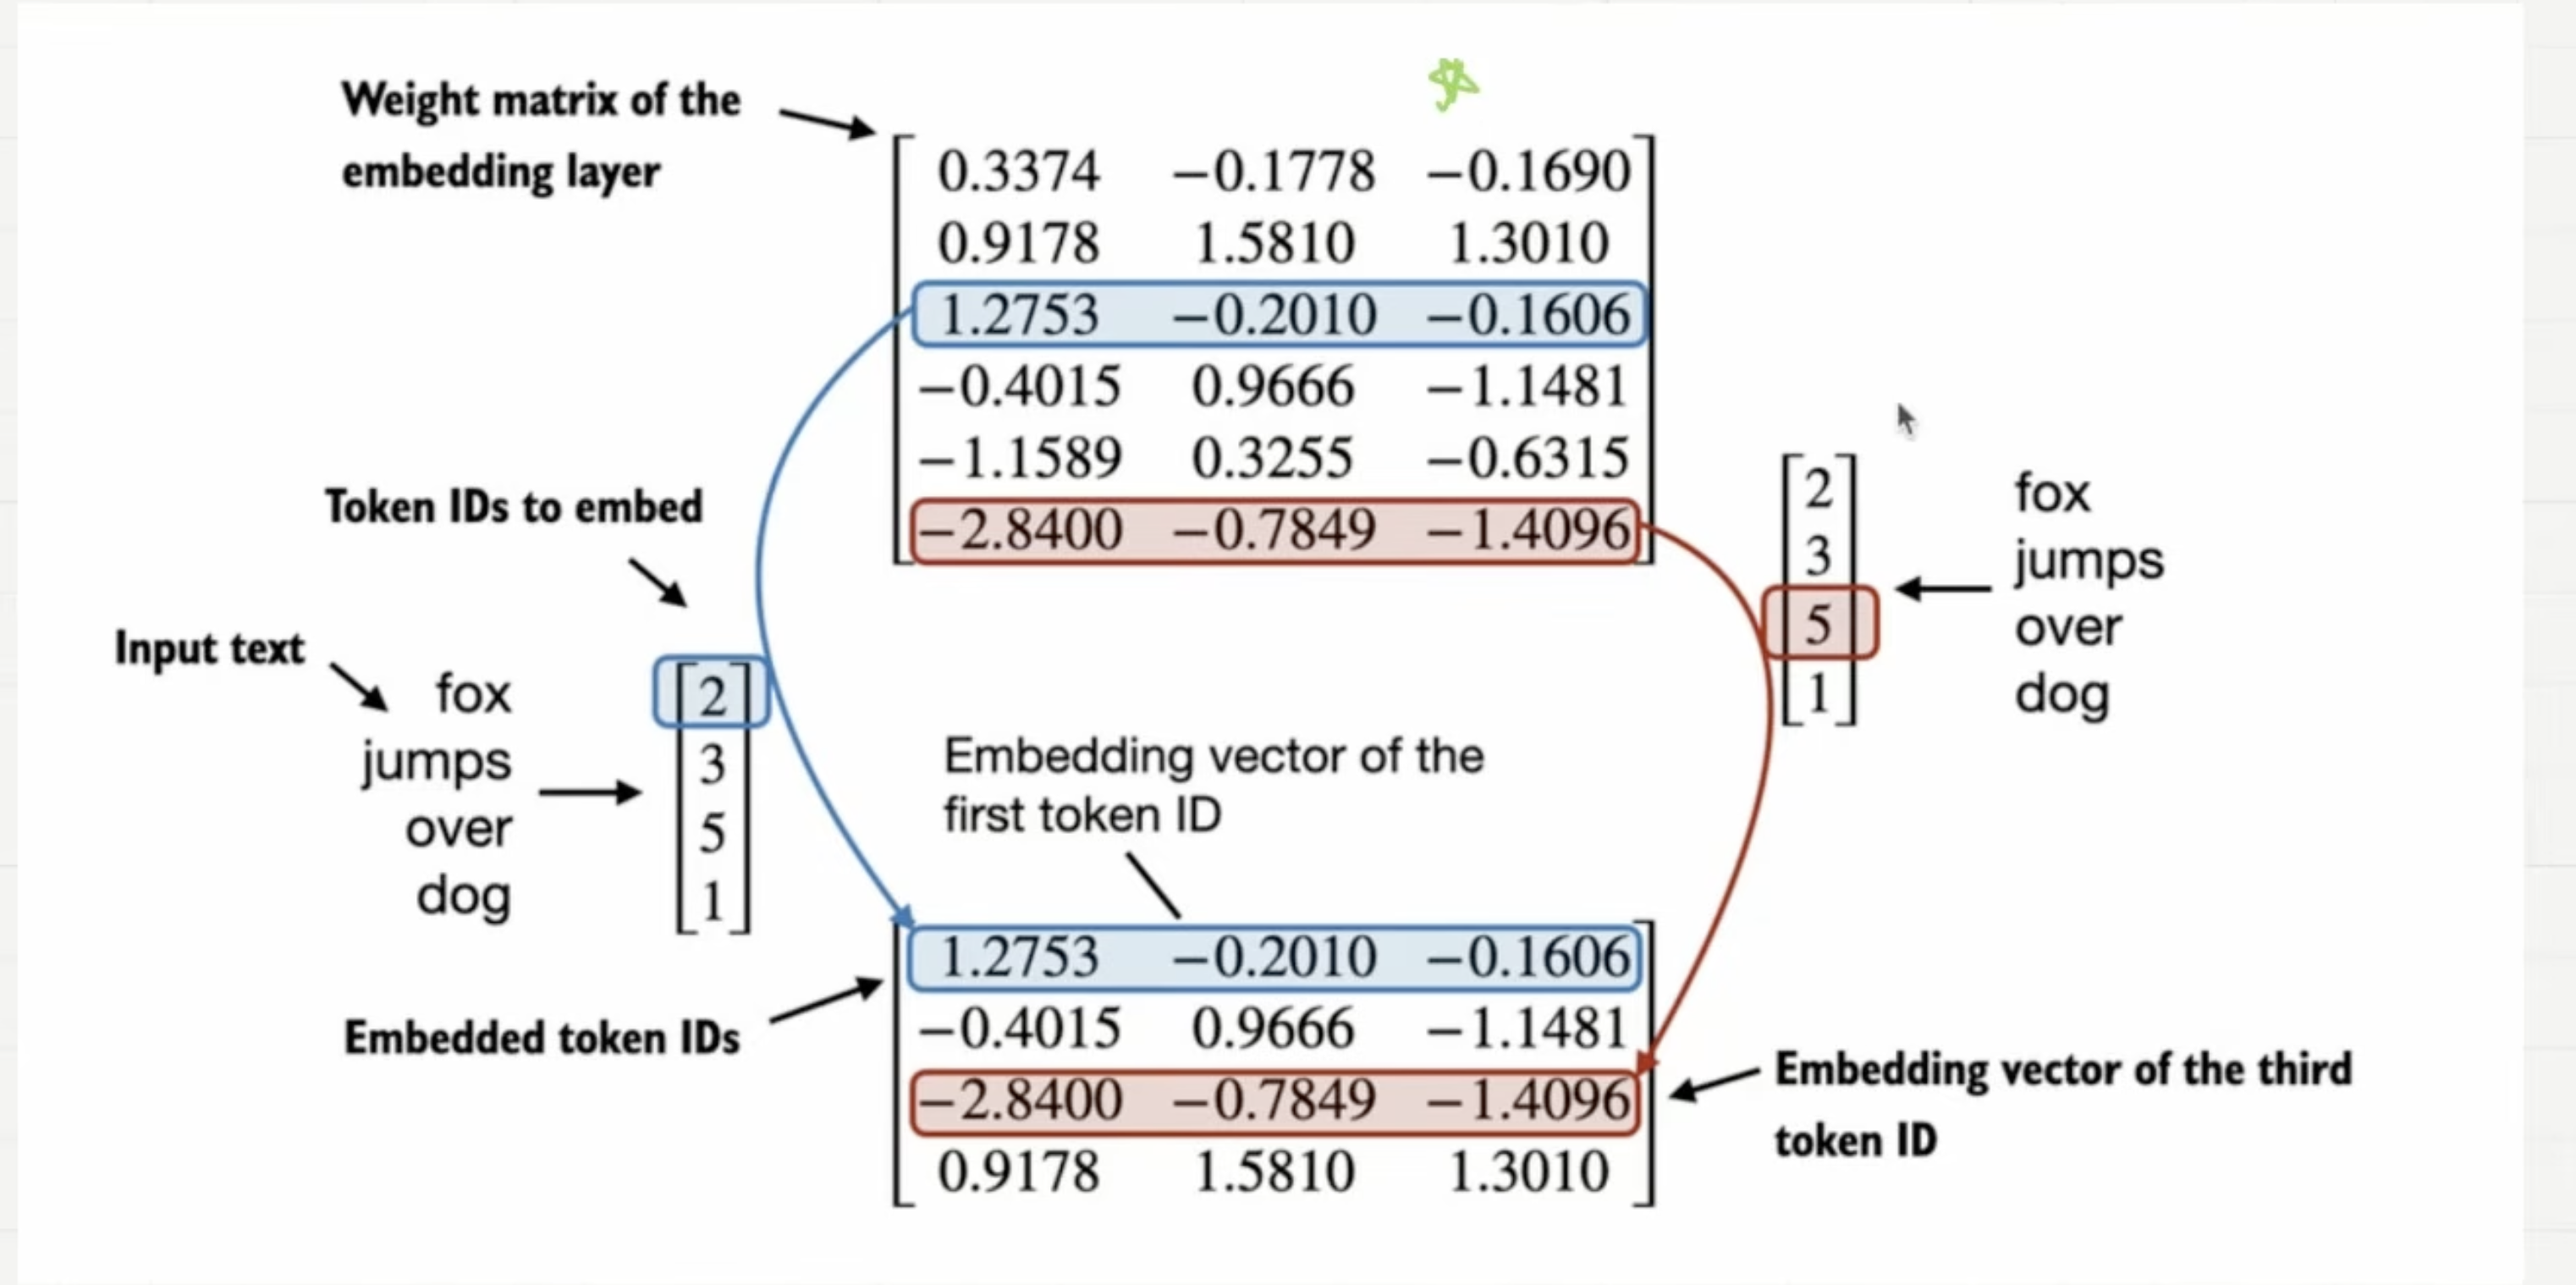